In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45449,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42917,Total threads: 8
Dashboard: http://127.0.0.1:44863/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:35475,


2026-03-05 11:30:18,332 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f35ebc03740>, <Task finished name='Task-4792127' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.o

### Load MITgcm Output from Assimilations

In [2]:
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/OSCAR/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
from xmitgcm import open_mdsdataset

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-08-31 12:0:0',delta_t=1200)

num_diags = 30+31+offset # nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-10-31 12:0:0',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-12-31 12:0:0',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 + 1 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-02-28 12:0:0',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

In [5]:
dt = ds_tpose_TAO.time.diff("time")
dt_days = dt / np.timedelta64(1, "D")

dt_days.min().item(), dt_days.max().item()

(1.0, 1.0)

In [6]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30')) # subset to sep 2012, june 2013
ds_tpose_TAO = ds_tpose_TAO.sel(time=slice('2012-09-01','2013-06-30')) # subset to sep 2012, june 2013

In [7]:
ds_tpose_TAO.isel(time=-1).time

<xarray.DataArray 'time' ()> Size: 8B
array('2013-06-30T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    iter     int64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2013-06-30T12:00:00
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

### Load TAO U and V

In [8]:
ds_OSCAR = xr.open_dataset('/home/edavenport/oscar_2012_2013.nc')
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
ds_OSCAR = ds_OSCAR.rename({'lat':'YC','lon':'XC'})
ds_OSCAR = ds_OSCAR.swap_dims({'latitude':'YC','longitude':'XC'})
ds_OSCAR = ds_OSCAR.transpose('time','YC','XC')
ds_OSCAR = ds_OSCAR.assign_coords(time=ds_OSCAR.indexes['time'].to_datetimeindex())
ds_OSCAR = ds_OSCAR.where(ds_OSCAR.XC <= 290, drop=True) # subset to 120E-260E
ds_OSCAR = ds_OSCAR.where(ds_OSCAR.XC >= 110, drop=True) 
ds_OSCAR = ds_OSCAR.where(ds_OSCAR.YC >= -20, drop=True) # subset to 20S-20N
ds_OSCAR = ds_OSCAR.where(ds_OSCAR.YC <= 20, drop=True)

/tmp/ipykernel_610363/3986941353.py:6: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ds_OSCAR = ds_OSCAR.assign_coords(time=ds_OSCAR.indexes['time'].to_datetimeindex())
/tmp/ipykernel_610363/3986941353.py:6: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_OSCAR = ds_OSCAR.assign_coords(time=ds_OSCAR.indexes['time'].to_datetimeindex())


In [9]:
ds_OSCAR = ds_OSCAR.sel(time=slice('2012-09-01','2013-06-30')) # subset to sep 2012, june 2013

In [10]:
import xgcm
grid = xgcm.Grid(ds_tpose_TAO, periodic=False)
tpose_TAO_U = grid.interp(ds_tpose_TAO.UVEL, 'X')
tpose_TAO_V = grid.interp(ds_tpose_TAO.VVEL, 'Y')
grid = xgcm.Grid(ds_tpose_noTAO, periodic=False)
tpose_noTAO_U = grid.interp(ds_tpose_noTAO.UVEL, 'X')
tpose_noTAO_V = grid.interp(ds_tpose_noTAO.VVEL, 'Y')

In [11]:
tpose_U_noTAO = tpose_noTAO_U.isel(Z=0).interp(XC=ds_OSCAR.XC, YC=ds_OSCAR.YC).squeeze()
tpose_U_TAO = tpose_TAO_U.isel(Z=0).interp(XC=ds_OSCAR.XC, YC=ds_OSCAR.YC).squeeze()
tpose_V_noTAO = tpose_noTAO_V.isel(Z=0).interp(XC=ds_OSCAR.XC, YC=ds_OSCAR.YC).squeeze()
tpose_V_TAO = tpose_TAO_V.isel(Z=0).interp(XC=ds_OSCAR.XC, YC=ds_OSCAR.YC).squeeze()

In [12]:
tpose_U_noTAO.time
# ds_OSCAR.time

<xarray.DataArray 'time' (time: 303)> Size: 2kB
array(['2012-09-01T12:00:00.000000000', '2012-09-02T12:00:00.000000000',
       '2012-09-03T12:00:00.000000000', ..., '2013-06-28T12:00:00.000000000',
       '2013-06-29T12:00:00.000000000', '2013-06-30T12:00:00.000000000'],
      shape=(303,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2kB 2012-09-01T12:00:00 ... 2013-06-30T12:...
    Z        float64 8B -1.0
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

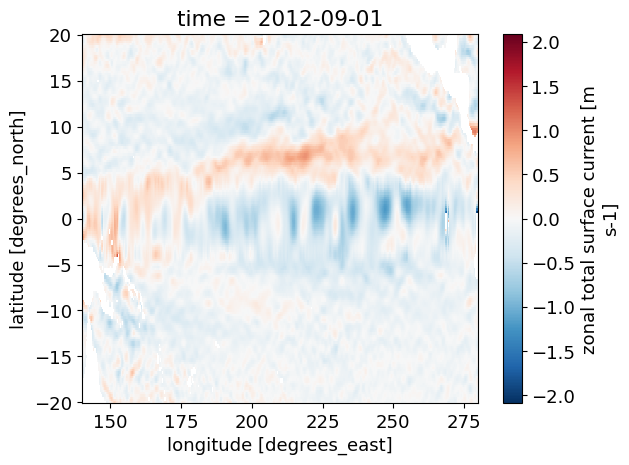

In [13]:
ds_OSCAR.u.isel(time=0).plot()

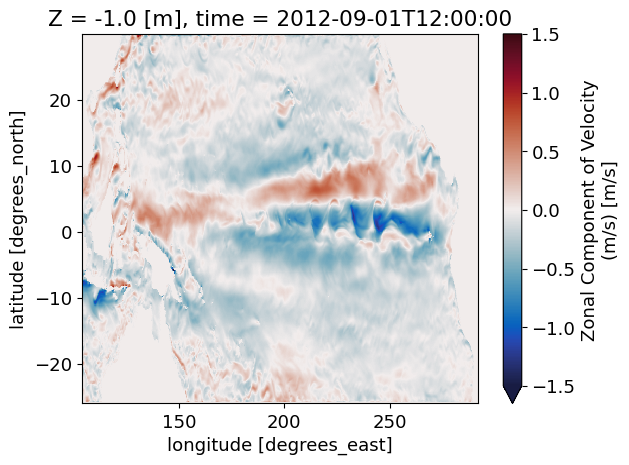

In [14]:
tpose_TAO_U.isel(Z=0).isel(time=0).plot(vmin=-1.5,vmax=1.5,cmap=cmo.balance)

In [15]:
tpose_U_noTAO.isel(time=-1).time

<xarray.DataArray 'time' ()> Size: 8B
array('2013-06-30T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    Z        float64 8B -1.0
    time     datetime64[ns] 8B 2013-06-30T12:00:00
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

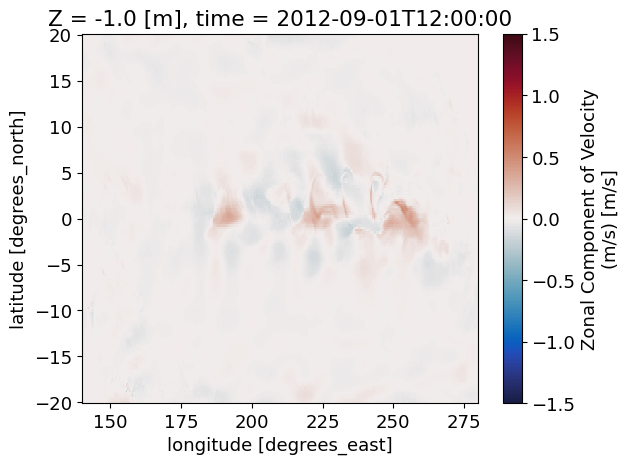

In [16]:
(tpose_U_TAO - tpose_U_noTAO).isel(time=0).plot(vmin=-1.5,vmax=1.5,cmap=cmo.balance)

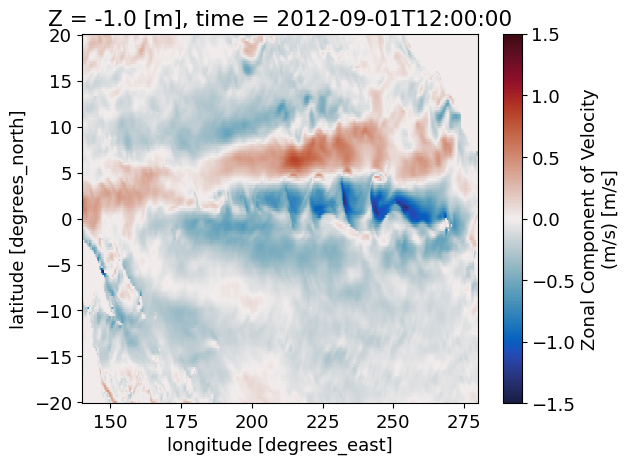

In [17]:
tpose_U_noTAO.isel(time=0).plot(vmin=-1.5,vmax=1.5,cmap=cmo.balance)

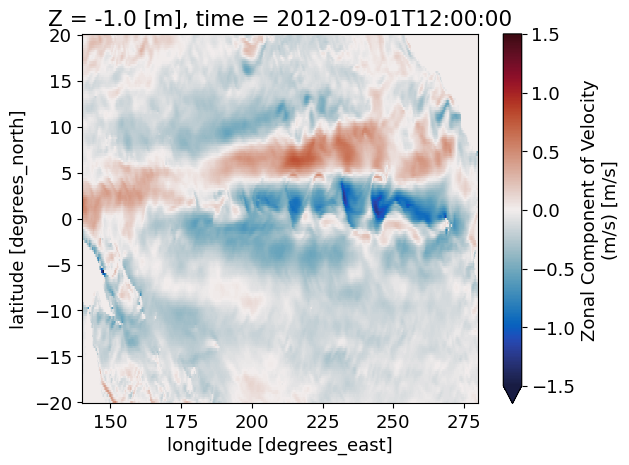

In [18]:
tpose_U_TAO.isel(time=0).plot(vmin=-1.5,vmax=1.5,cmap=cmo.balance)

In [19]:
oscar_mean_u = ds_OSCAR.u.mean('time')
oscar_mean_v = ds_OSCAR.v.mean('time')
tpose_noTAO_mean_u = tpose_U_noTAO.mean('time')
tpose_noTAO_mean_v = tpose_V_noTAO.mean('time')
tpose_TAO_mean_u = tpose_U_TAO.mean('time')
tpose_TAO_mean_v = tpose_V_TAO.mean('time')

In [20]:
oscar_mean_u.XC

<xarray.DataArray 'XC' (XC: 561)> Size: 4kB
array([140.  , 140.25, 140.5 , ..., 279.5 , 279.75, 280.  ], shape=(561,))
Coordinates:
  * XC       (XC) float64 4kB 140.0 140.2 140.5 140.8 ... 279.5 279.8 280.0
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east
    axis:           X
    valid_min:      0.0
    valid_max:      359.75
    bounds:         [0,359.75]

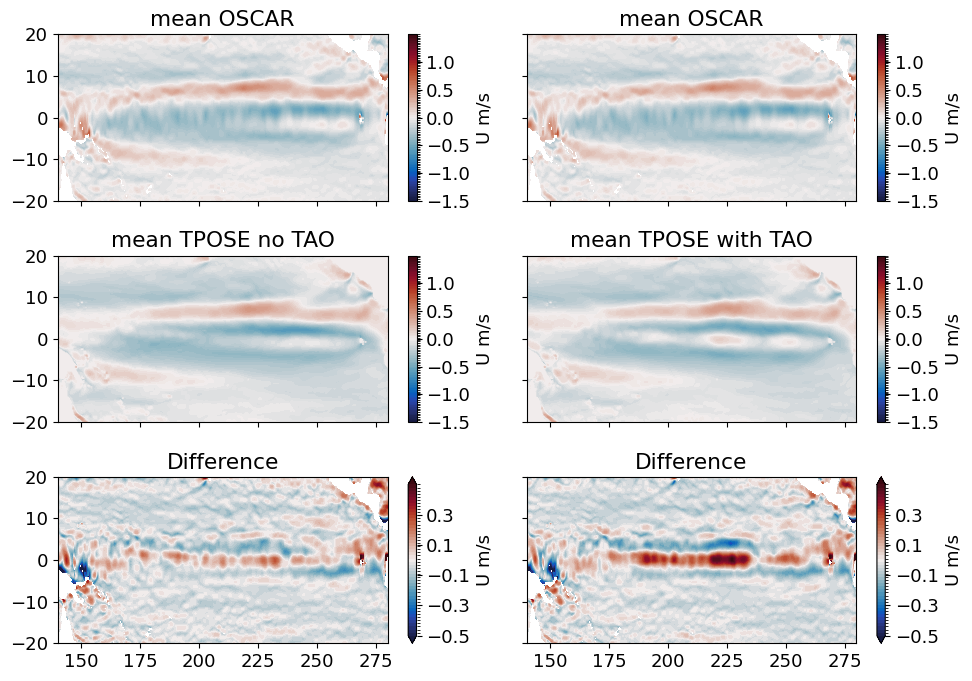

In [41]:
ticks = np.arange(-1.5,1.5,0.5)
diff_ticks = np.arange(-0.5,0.5,0.2)
levels = np.linspace(-1.5,1.5,100)
fig, ax = plt.subplots(figsize=(10,7),nrows=3,ncols=2,sharex=True,sharey=True)
cf = oscar_mean_u.plot.contourf(ax=ax[0,0],y='YC',levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[0,0].set_title('mean OSCAR')  
cf.colorbar.set_ticks(ticks)
cf = tpose_noTAO_mean_u.plot.contourf(ax=ax[1,0],y='YC',levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[1,0].set_title('mean TPOSE no TAO')
cf.colorbar.set_ticks(ticks)
cf = (tpose_noTAO_mean_u - oscar_mean_u).plot.contourf(ax=ax[2,0],y='YC',levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'U m/s'})
ax[2,0].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

cf = oscar_mean_u.plot.contourf(ax=ax[0,1],y='YC',levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[0,1].set_title('mean OSCAR')
cf.colorbar.set_ticks(ticks)
cf = tpose_TAO_mean_u.plot.contourf(ax=ax[1,1],y='YC',levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[1,1].set_title('mean TPOSE with TAO')
cf.colorbar.set_ticks(ticks)
cf = (tpose_TAO_mean_u - oscar_mean_u).plot.contourf(ax=ax[2,1],y='YC',levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'U m/s'})
ax[2,1].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

for ax in ax.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
fig.savefig(foldername + 'mean_u_comparison.png',dpi=300)

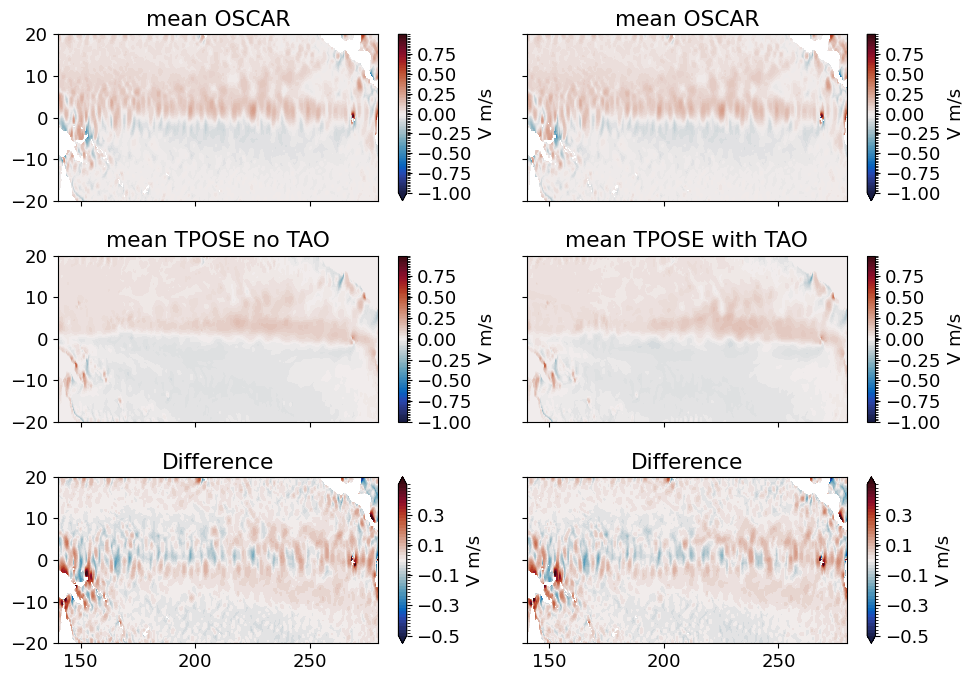

In [40]:
ticks = np.arange(-1.0,1.0,0.25)
diff_ticks = np.arange(-0.5,0.5,0.2)
levels = np.linspace(-1.0,1.0,100)
fig, ax = plt.subplots(figsize=(10,7),nrows=3,ncols=2,sharex=True,sharey=True)
cf = oscar_mean_v.plot.contourf(ax=ax[0,0],levels=levels,cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':'V m/s'})
ax[0,0].set_title('mean OSCAR')  
cf.colorbar.set_ticks(ticks)
cf = tpose_noTAO_mean_v.plot.contourf(ax=ax[1,0],levels=levels,cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':'V m/s'})
ax[1,0].set_title('mean TPOSE no TAO')
cf.colorbar.set_ticks(ticks)
cf = (tpose_noTAO_mean_v - oscar_mean_v).plot.contourf(ax=ax[2,0],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'V m/s'})
ax[2,0].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

cf = oscar_mean_v.plot.contourf(ax=ax[0,1],levels=levels,cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':'V m/s'})
ax[0,1].set_title('mean OSCAR')
cf.colorbar.set_ticks(ticks)
cf = tpose_TAO_mean_v.plot.contourf(ax=ax[1,1],levels=levels,cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':'V m/s'})
ax[1,1].set_title('mean TPOSE with TAO')
cf.colorbar.set_ticks(ticks)
cf = (tpose_TAO_mean_v - oscar_mean_v).plot.contourf(ax=ax[2,1],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'V m/s'})
ax[2,1].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

for ax in ax.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
fig.savefig(foldername + 'mean_v_comparison.png',dpi=300)

In [25]:
oscar_std_u = ds_OSCAR.u.std('time')
oscar_std_v = ds_OSCAR.v.std('time')
tpose_noTAO_std_u = tpose_U_noTAO.std('time')
tpose_noTAO_std_v = tpose_V_noTAO.std('time')
tpose_TAO_std_u = tpose_U_TAO.std('time')
tpose_TAO_std_v = tpose_V_TAO.std('time')

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


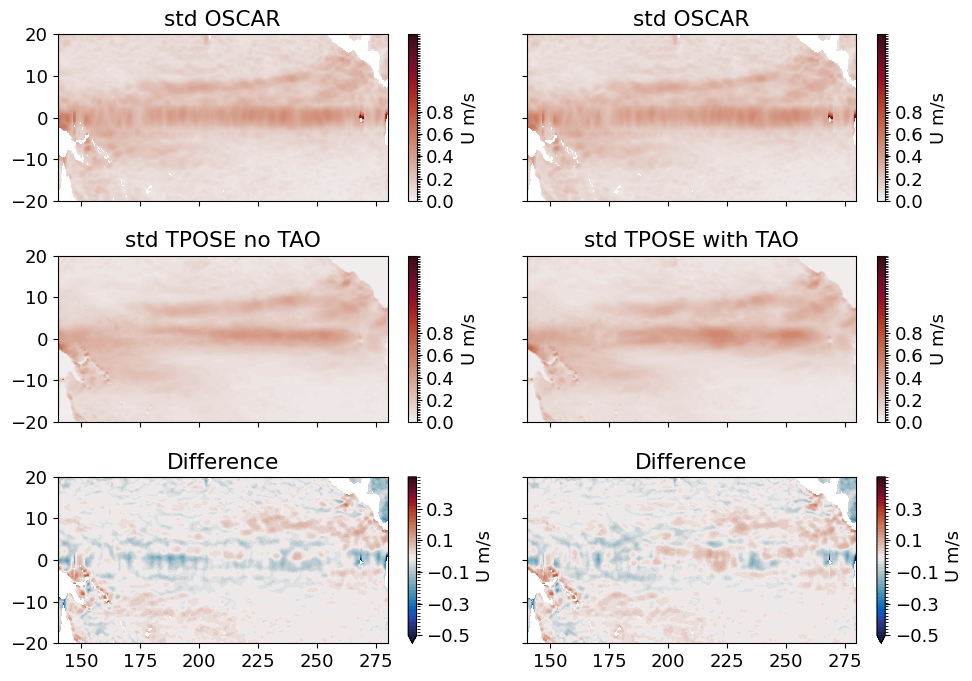

In [39]:
ticks = np.arange(0,1.0,0.2)
diff_ticks = np.arange(-0.5,0.5,0.2)
levels = np.linspace(0,1.5,100)
fig, ax = plt.subplots(figsize=(10,7),nrows=3,ncols=2,sharex=True,sharey=True)
cf = oscar_std_u.plot.contourf(ax=ax[0,0],levels=levels,cmap=cmo.amp,vmin=0,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[0,0].set_title('std OSCAR')  
cf.colorbar.set_ticks(ticks)
cf = tpose_noTAO_std_u.plot.contourf(ax=ax[1,0],levels=levels,cmap=cmo.amp,vmin=0,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[1,0].set_title('std TPOSE no TAO')
cf.colorbar.set_ticks(ticks)
cf = (tpose_noTAO_std_u - oscar_std_u).plot.contourf(ax=ax[2,0],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'U m/s'})
ax[2,0].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

cf = oscar_std_u.plot.contourf(ax=ax[0,1],levels=levels,cmap=cmo.amp,vmin=0,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[0,1].set_title('std OSCAR')
cf.colorbar.set_ticks(ticks)
cf = tpose_TAO_std_u.plot.contourf(ax=ax[1,1],levels=levels,cmap=cmo.amp,vmin=0,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[1,1].set_title('std TPOSE with TAO')
cf.colorbar.set_ticks(ticks)
cf = (tpose_TAO_std_u - oscar_std_u).plot.contourf(ax=ax[2,1],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'U m/s'})
ax[2,1].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

for ax in ax.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
fig.savefig(foldername + 'std_u_comparison.png',dpi=300)

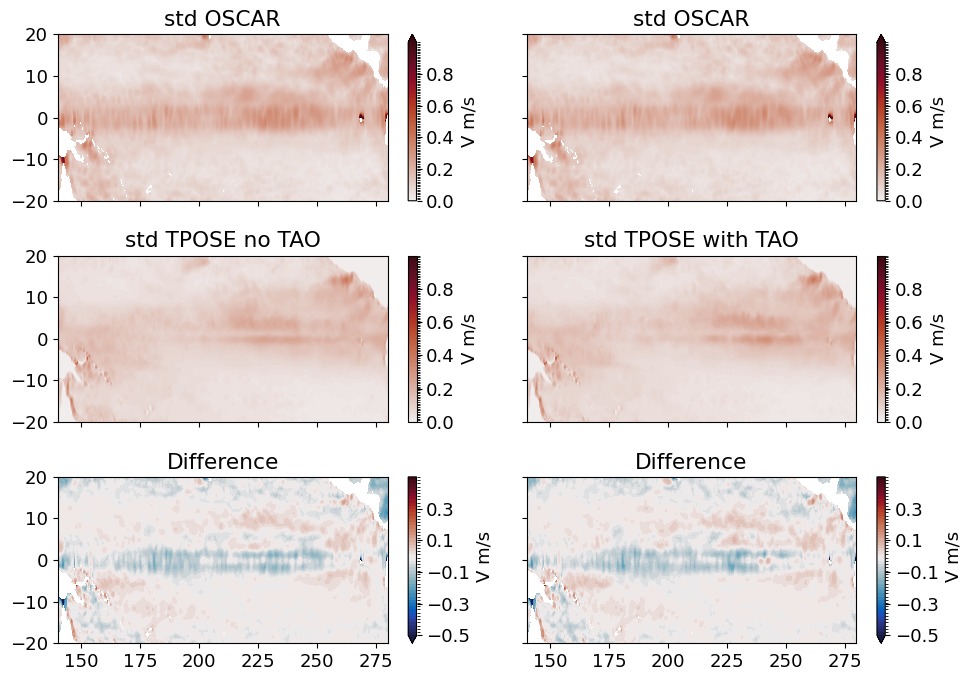

In [36]:
ticks = np.arange(0,1.0,0.2)
diff_ticks = np.arange(-0.5,0.5,0.2)
levels = np.linspace(0,1.0,100)
fig, ax = plt.subplots(figsize=(10,7),nrows=3,ncols=2,sharex=True,sharey=True)
cf = oscar_std_v.plot.contourf(ax=ax[0,0],levels=levels,cmap=cmo.amp,vmin=0,vmax=1.0,cbar_kwargs={'label':'V m/s'})
ax[0,0].set_title('std OSCAR')  
cf.colorbar.set_ticks(ticks)
cf = tpose_noTAO_std_v.plot.contourf(ax=ax[1,0],levels=levels,cmap=cmo.amp,vmin=0,vmax=1.0,cbar_kwargs={'label':'V m/s'})
ax[1,0].set_title('std TPOSE no TAO')
cf.colorbar.set_ticks(ticks)
cf = (tpose_noTAO_std_v - oscar_std_v).plot.contourf(ax=ax[2,0],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'V m/s'})
ax[2,0].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

cf = oscar_std_v.plot.contourf(ax=ax[0,1],levels=levels,cmap=cmo.amp,vmin=0,vmax=1.0,cbar_kwargs={'label':'V m/s'})
ax[0,1].set_title('std OSCAR')
cf.colorbar.set_ticks(ticks)
cf = tpose_TAO_std_v.plot.contourf(ax=ax[1,1],levels=levels,cmap=cmo.amp,vmin=0,vmax=1.0,cbar_kwargs={'label':'V m/s'})
ax[1,1].set_title('std TPOSE with TAO')
cf.colorbar.set_ticks(ticks)
cf = (tpose_TAO_std_v - oscar_std_v).plot.contourf(ax=ax[2,1],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'V m/s'})
ax[2,1].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

for ax in ax.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
fig.savefig(foldername + 'std_v_comparison.png',dpi=300)

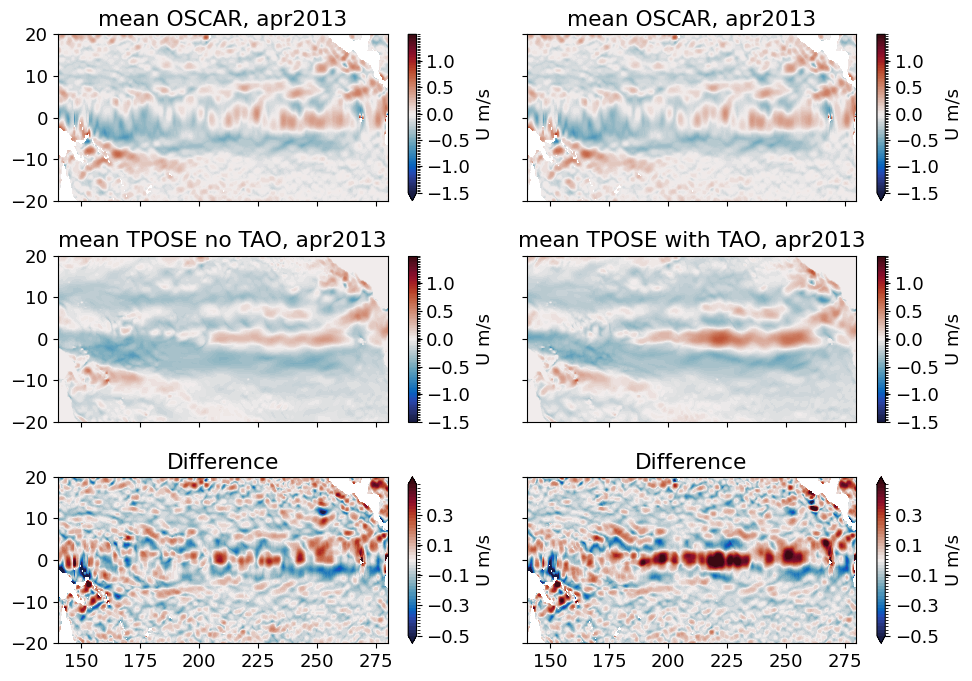

In [37]:
oscar = ds_OSCAR.u.sel(time=slice('2013-04-01','2013-04-30')).mean(dim='time')
tpose_TAO = tpose_U_TAO.sel(time=slice('2013-04-01','2013-04-30')).mean(dim='time')
tpose_noTAO = tpose_U_noTAO.sel(time=slice('2013-04-01','2013-04-30')).mean(dim='time')

ticks = np.arange(-1.5,1.5,0.5)
diff_ticks = np.arange(-0.5,0.5,0.2)
levels = np.linspace(-1.5,1.5,100)
fig, ax = plt.subplots(figsize=(10,7),nrows=3,ncols=2,sharex=True,sharey=True)
cf = oscar.plot.contourf(ax=ax[0,0],levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[0,0].set_title('mean OSCAR, apr2013') 
cf.colorbar.set_ticks(ticks) 
cf = tpose_noTAO.plot.contourf(ax=ax[1,0],levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[1,0].set_title('mean TPOSE no TAO, apr2013')
cf.colorbar.set_ticks(ticks)
cf = (tpose_noTAO - oscar).plot.contourf(ax=ax[2,0],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'U m/s'})
ax[2,0].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

cf = oscar.plot.contourf(ax=ax[0,1],levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[0,1].set_title('mean OSCAR, apr2013')
cf.colorbar.set_ticks(ticks)
cf = tpose_TAO.plot.contourf(ax=ax[1,1],levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[1,1].set_title('mean TPOSE with TAO, apr2013')
cf.colorbar.set_ticks(ticks)
cf = (tpose_TAO - oscar).plot.contourf(ax=ax[2,1],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'U m/s'})
ax[2,1].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

for ax in ax.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
fig.savefig(foldername + 'mean_u_comparison_april.png',dpi=300)

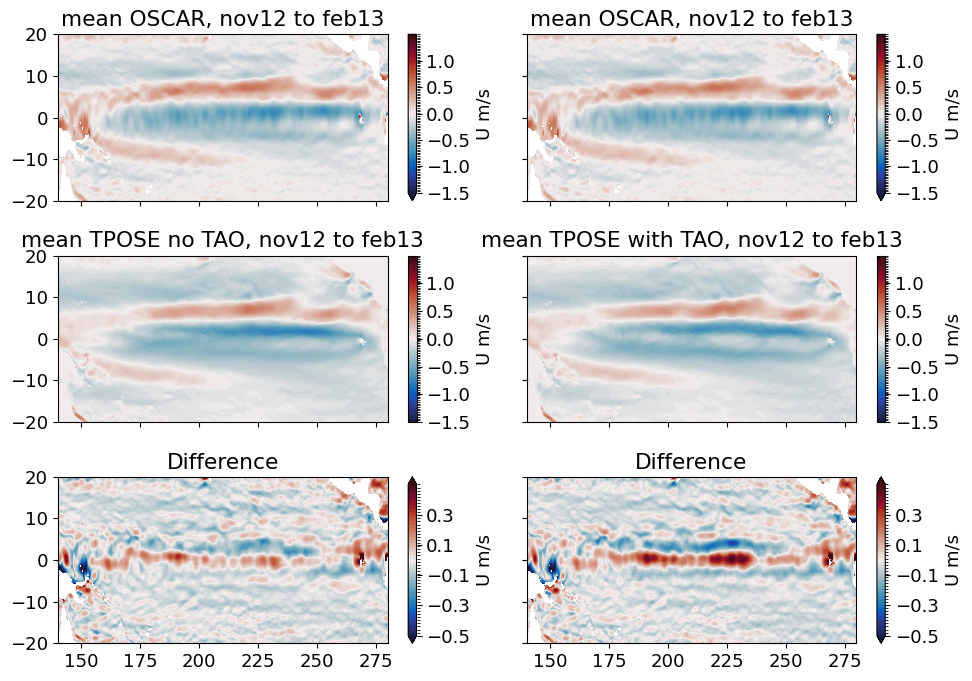

In [38]:
oscar = ds_OSCAR.u.sel(time=slice('2012-09-01','2013-02-28')).mean(dim='time')
tpose_TAO = tpose_U_TAO.sel(time=slice('2012-09-01','2013-02-28')).mean(dim='time')
tpose_noTAO = tpose_U_noTAO.sel(time=slice('2012-09-01','2013-02-28')).mean(dim='time')

ticks = np.arange(-1.5,1.5,0.5)
diff_ticks = np.arange(-0.5,0.5,0.2)
fig, ax = plt.subplots(figsize=(10,7),nrows=3,ncols=2,sharex=True,sharey=True)
cf = oscar.plot.contourf(ax=ax[0,0],levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[0,0].set_title('mean OSCAR, nov12 to feb13') 
cf.colorbar.set_ticks(ticks) 
cf = tpose_noTAO.plot.contourf(ax=ax[1,0],levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[1,0].set_title('mean TPOSE no TAO, nov12 to feb13')
cf.colorbar.set_ticks(ticks)
cf = (tpose_noTAO - oscar).plot.contourf(ax=ax[2,0],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'U m/s'})
ax[2,0].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

cf = oscar.plot.contourf(ax=ax[0,1],levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[0,1].set_title('mean OSCAR, nov12 to feb13')
cf.colorbar.set_ticks(ticks)
cf = tpose_TAO.plot.contourf(ax=ax[1,1],levels=levels,cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'U m/s'})
ax[1,1].set_title('mean TPOSE with TAO, nov12 to feb13')
cf.colorbar.set_ticks(ticks)
cf = (tpose_TAO - oscar).plot.contourf(ax=ax[2,1],levels=np.linspace(-0.5,0.5,50),cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'U m/s'})
ax[2,1].set_title('Difference')
cf.colorbar.set_ticks(diff_ticks)

for ax in ax.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
fig.savefig(foldername + 'mean_u_comparison_novtofeb.png',dpi=300)

### TAO Surface Currents

In [93]:
profile_path = '/data/SO3/edavenport/tpose6/mar2013/run_ad/PROF_iter15/PROF_eq/TAO_WO_2013_CUR_model.nc'
ds_cur = xr.open_dataset(profile_path)

In [94]:
import pandas as pd
dates = ds_cur['prof_YYYYMMDD'].values.astype(int)
times = ds_cur['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_cur = ds_cur.assign_coords(time=('iPROF', datetimes))
# ds_cur = ds_cur.swap_dims({'iPROF': 'time'})
ds_cur = ds_cur.assign_coords(depth=('iDEPTH', ds_cur['prof_depth'].values*-1))
# ds_cur = ds_cur.swap_dims({'iDEPTH': 'depth'})
ds_cur = ds_cur.assign_coords(lat=('iPROF', ds_cur['prof_lat'].values))
ds_cur = ds_cur.assign_coords(lon=('iPROF', ds_cur['prof_lon'].values))

# group profiles by longitude (these are all equatorial TAO moorings)
cur_by_lon = ds_cur.groupby('lon')

In [96]:
cur_by_lon[-170]

<xarray.Dataset> Size: 8MB
Dimensions:        (iPROF: 8783, iDEPTH: 16)
Coordinates:
    time           (iPROF) datetime64[ns] 70kB 2012-12-31T01:00:00 ... 2013-1...
    depth          (iDEPTH) float64 128B -10.0 -12.0 -15.0 ... -200.0 -202.0
    lat            (iPROF) float64 70kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon            (iPROF) float64 70kB -170.0 -170.0 -170.0 ... -170.0 -170.0
Dimensions without coordinates: iPROF, iDEPTH
Data variables:
    prof_YYYYMMDD  (iPROF) float64 70kB 2.012e+07 2.012e+07 ... 2.013e+07
    prof_HHMMSS    (iPROF) float64 70kB 1e+04 2e+04 3e+04 ... 2.2e+05 2.3e+05
    prof_lon       (iPROF) float64 70kB -170.0 -170.0 -170.0 ... -170.0 -170.0
    prof_lat       (iPROF) float64 70kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    prof_depth     (iDEPTH) float64 128B 10.0 12.0 15.0 ... 150.0 200.0 202.0
    prof_descr     (iPROF) |S30 263kB ...
    prof_U         (iPROF, iDEPTH) float64 1MB ...
    prof_Uweight   (iPROF, iDEPTH) float64 1MB ...
    prof_V         (iPROF, iDEPTH) float64 1MB ...
    prof_Vweight   (iPROF, iDEPTH) float64 1MB ...
    prof_Uestim    (iPROF, iDEPTH) float64 1MB ...
    prof_Vestim    (iPROF, iDEPTH) float64 1MB ...
Attributes:
    Format:   The contents of this MITprof file were processed \nusing the MI...
    date:     02-Mar-2026

In [97]:
def slice_by_time_keep_lon(group, start_time, end_time=None):
    """
    Slice a group (Dataset) by time without overwriting lon.
    
    group: xarray Dataset for a single lon
    start_time: np.datetime64 or string
    """
    # Boolean mask along the profile dimension (iPROF)
    mask = group.time >= np.datetime64(start_time)

    if end_time is not None:
        mask &= group.time <= np.datetime64(end_time)
    
    # Select the profiles, keep all coordinates intact
    return group.isel(iPROF=mask)

In [99]:
len(np.unique(cur_by_lon[-170.0].prof_U.time))

8783

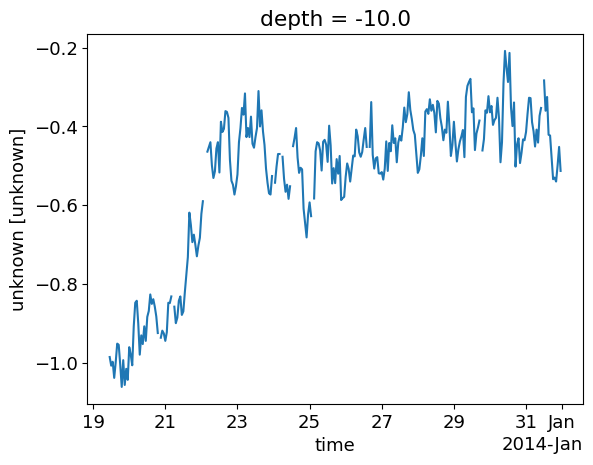

In [102]:
cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_U.plot(x='time')

In [90]:
cur_by_lon[-170.0].prof_lon

<xarray.DataArray 'prof_lon' (time: 26349)> Size: 211kB
array([ 147.,  147.,  147., ..., -170., -170., -170.], shape=(26349,))
Coordinates:
  * time     (time) datetime64[ns] 211kB 2012-12-31T01:00:00 ... 2013-12-31T2...
Attributes:
    long_name:  Longitude (degree East)
    units:      degrees_east

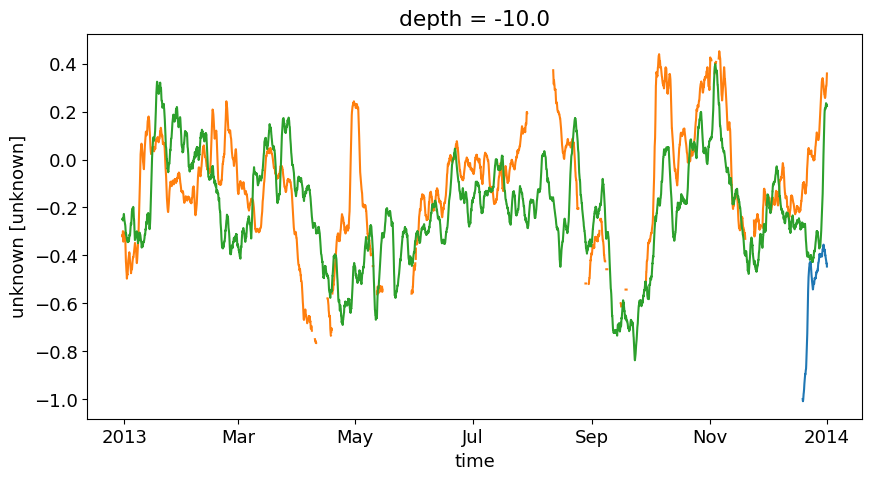

In [104]:
fig, ax = plt.subplots(figsize=(10,5))
cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax,x='time',label='TPOSE')
cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax,x='time',label='TPOSE')
cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax,x='time',label='TPOSE')


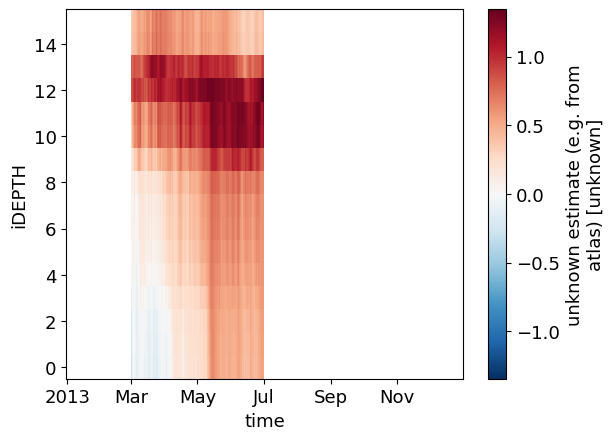

In [112]:
cur_by_lon[-170.0].sortby('time').prof_Uestim.plot(x='time')

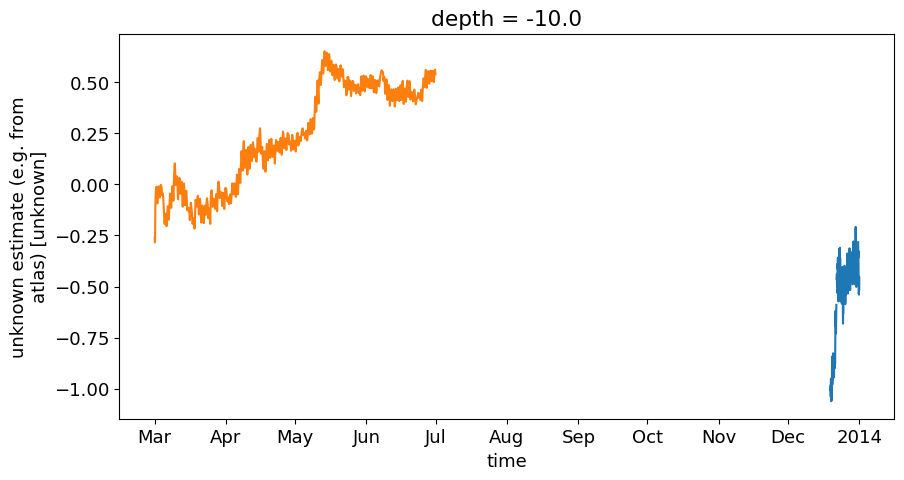

In [109]:
fig, ax = plt.subplots(figsize=(10,5))
cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_U.plot(ax=ax,x='time',label='TPOSE')
cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_Uestim.plot(ax=ax,x='time',label='TAO')

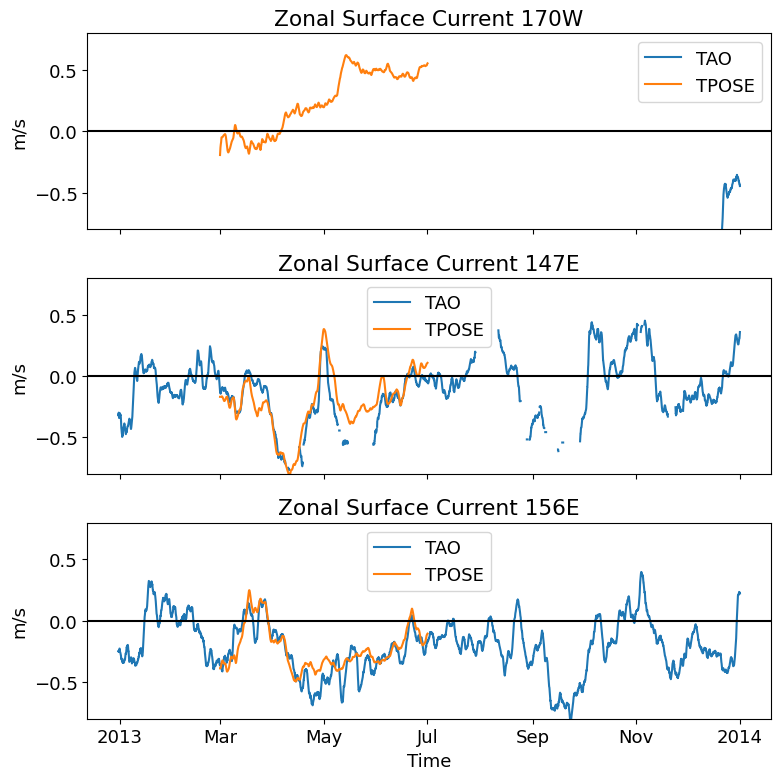

In [118]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,sharex=True)
cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[0],x='time',label='TAO')
cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_Uestim.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[0],x='time',label='TPOSE')
ax[0].legend()
ax[0].set_xlabel('')
ax[0].set_ylabel('m/s')
ax[0].set_title('Zonal Surface Current 170W')

cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[1],x='time',label='TAO')
cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_Uestim.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[1],x='time',label='TPOSE')
ax[1].legend()
ax[1].set_xlabel('')
ax[1].set_ylabel('m/s')
ax[1].set_title('Zonal Surface Current 147E')

cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[2],x='time',label='TAO')
cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_Uestim.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[2],x='time',label='TPOSE')
ax[2].legend()
ax[2].set_xlabel('Time')
ax[2].set_ylabel('m/s')
ax[2].set_title('Zonal Surface Current 156E')

for ax in ax.flatten():
    ax.axhline(0,color='k')
    ax.set_ylim(-0.8,0.8)
plt.tight_layout()
fig.savefig(foldername + 'tpose_TAO_curr_timseries.png',dpi=300)

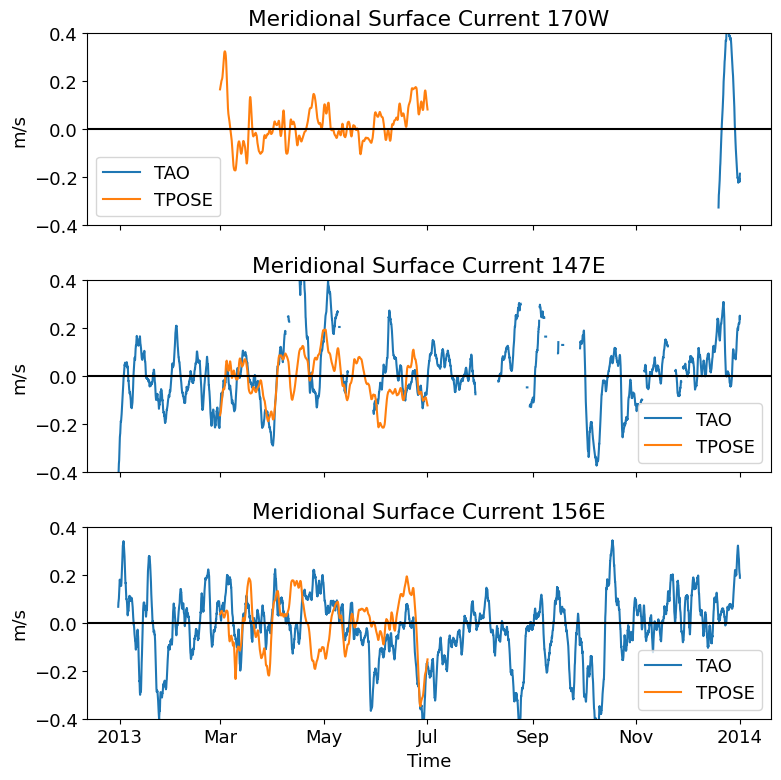

In [121]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,sharex=True)
cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[0],x='time',label='TAO')
cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_Vestim.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[0],x='time',label='TPOSE')
ax[0].legend()
ax[0].set_xlabel('')
ax[0].set_ylabel('m/s')
ax[0].set_title('Meridional Surface Current 170W')

cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[1],x='time',label='TAO')
cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_Vestim.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[1],x='time',label='TPOSE')
ax[1].legend()
ax[1].set_xlabel('')
ax[1].set_ylabel('m/s')
ax[1].set_title('Meridional Surface Current 147E')

cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[2],x='time',label='TAO')
cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_Vestim.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[2],x='time',label='TPOSE')
ax[2].legend()
ax[2].set_xlabel('Time')
ax[2].set_ylabel('m/s')
ax[2].set_title('Meridional Surface Current 156E')

for ax in ax.flatten():
    ax.axhline(0,color='k')
    ax.set_ylim(-0.4,0.4)
plt.tight_layout()
fig.savefig(foldername + 'tpose_TAO_curr_V_timseries.png',dpi=300)

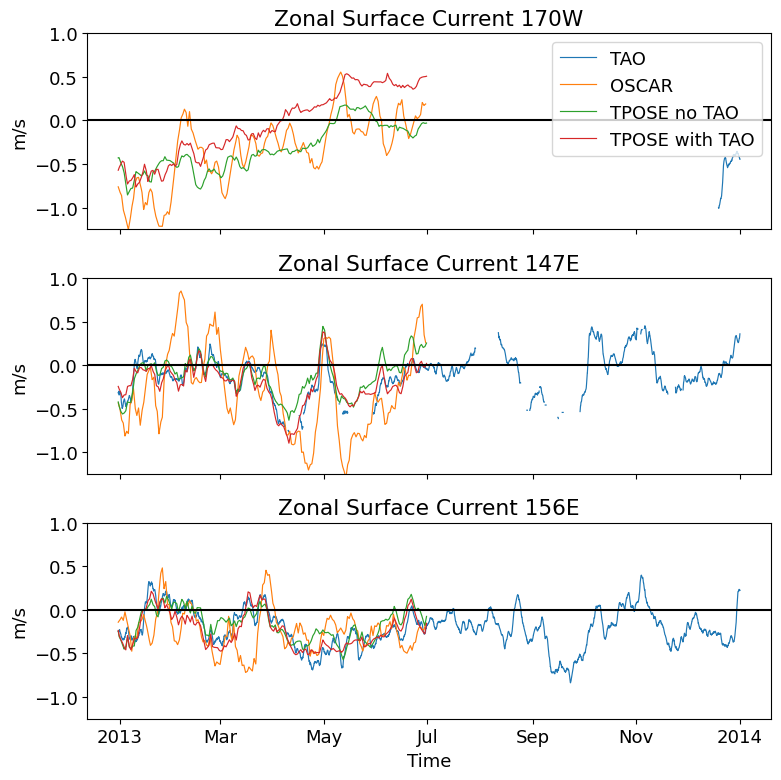

In [151]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,sharex=True)
tao_to_interp = cur_by_lon[-170.0].prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.u.interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))
tpose_notao_compare = tpose_noTAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))
tpose_tao_compare = tpose_TAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))

cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[0],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[0],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[0],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[0],x='time',lw=0.85,label='TPOSE with TAO')
ax[0].legend()
ax[0].set_xlabel('')
ax[0].set_ylabel('m/s')
ax[0].set_title('Zonal Surface Current 170W')

tao_to_interp = cur_by_lon[147.0].prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.u.interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))
tpose_notao_compare = tpose_noTAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))
tpose_tao_compare = tpose_TAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))

cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[1],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[1],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[1],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[1],x='time',lw=0.85,label='TPOSE with TAO')
# ax[1].legend()
ax[1].set_xlabel('')
ax[1].set_ylabel('m/s')
ax[1].set_title('Zonal Surface Current 147E')

tao_to_interp = cur_by_lon[156.0].prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.u.interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))
tpose_notao_compare = tpose_noTAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))
tpose_tao_compare = tpose_TAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))

cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[2],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[2],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[2],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[2],x='time',lw=0.85,label='TPOSE with TAO')
# ax[2].legend()
ax[2].set_xlabel('Time')
ax[2].set_ylabel('m/s')
ax[2].set_title('Zonal Surface Current 156E')

for ax in ax.flatten():
    ax.axhline(0,color='k')
    ax.set_ylim(-1.25,1.0)
plt.tight_layout()
fig.savefig(foldername + 'tpose_TAO_oscar_zonal_timseries.png',dpi=300)

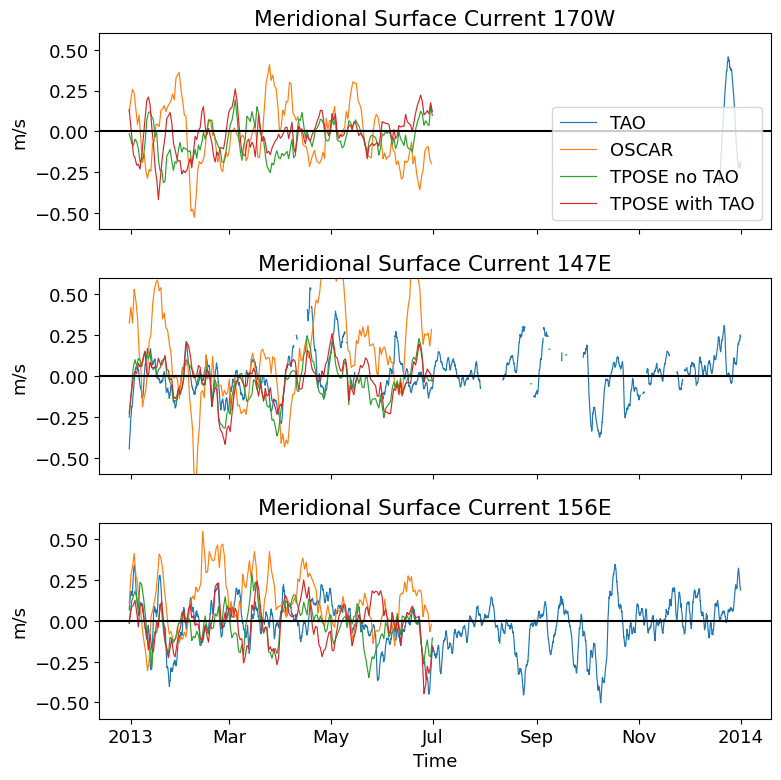

In [152]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,sharex=True)
tao_to_interp = cur_by_lon[-170.0].prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.v.interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))
tpose_notao_compare = tpose_noTAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))
tpose_tao_compare = tpose_TAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))

cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[0],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[0],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[0],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[0],x='time',lw=0.85,label='TPOSE with TAO')
ax[0].legend()
ax[0].set_xlabel('')
ax[0].set_ylabel('m/s')
ax[0].set_title('Meridional Surface Current 170W')

tao_to_interp = cur_by_lon[147.0].prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.v.interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))
tpose_notao_compare = tpose_noTAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))
tpose_tao_compare = tpose_TAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))

cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[1],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[1],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[1],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[1],x='time',lw=0.85,label='TPOSE with TAO')
# ax[1].legend()
ax[1].set_xlabel('')
ax[1].set_ylabel('m/s')
ax[1].set_title('Meridional Surface Current 147E')

tao_to_interp = cur_by_lon[156.0].prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.v.interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))
tpose_notao_compare = tpose_noTAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))
tpose_tao_compare = tpose_TAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))

cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[2],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[2],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[2],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[2],x='time',lw=0.85,label='TPOSE with TAO')
# ax[2].legend()
ax[2].set_xlabel('Time')
ax[2].set_ylabel('m/s')
ax[2].set_title('Meridional Surface Current 156E')

for ax in ax.flatten():
    ax.axhline(0,color='k')
    ax.set_ylim(-0.6,0.6)
plt.tight_layout()
fig.savefig(foldername + 'tpose_TAO_oscar_meridional_timseries.png',dpi=300)

In [155]:
profile_path = '/data/SO3/edavenport/tpose6/nov2012/run_iter0/PROF_eq/CUR/TAO_WO_2012_CUR_v2_model.nc'
ds_cur = xr.open_dataset(profile_path)

In [156]:
import pandas as pd
dates = ds_cur['prof_YYYYMMDD'].values.astype(int)
times = ds_cur['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_cur = ds_cur.assign_coords(time=('iPROF', datetimes))
# ds_cur = ds_cur.swap_dims({'iPROF': 'time'})
ds_cur = ds_cur.assign_coords(depth=('iDEPTH', ds_cur['prof_depth'].values*-1))
# ds_cur = ds_cur.swap_dims({'iDEPTH': 'depth'})
ds_cur = ds_cur.assign_coords(lat=('iPROF', ds_cur['prof_lat'].values))
ds_cur = ds_cur.assign_coords(lon=('iPROF', ds_cur['prof_lon'].values))

# group profiles by longitude (these are all equatorial TAO moorings)
cur_by_lon = ds_cur.groupby('lon')

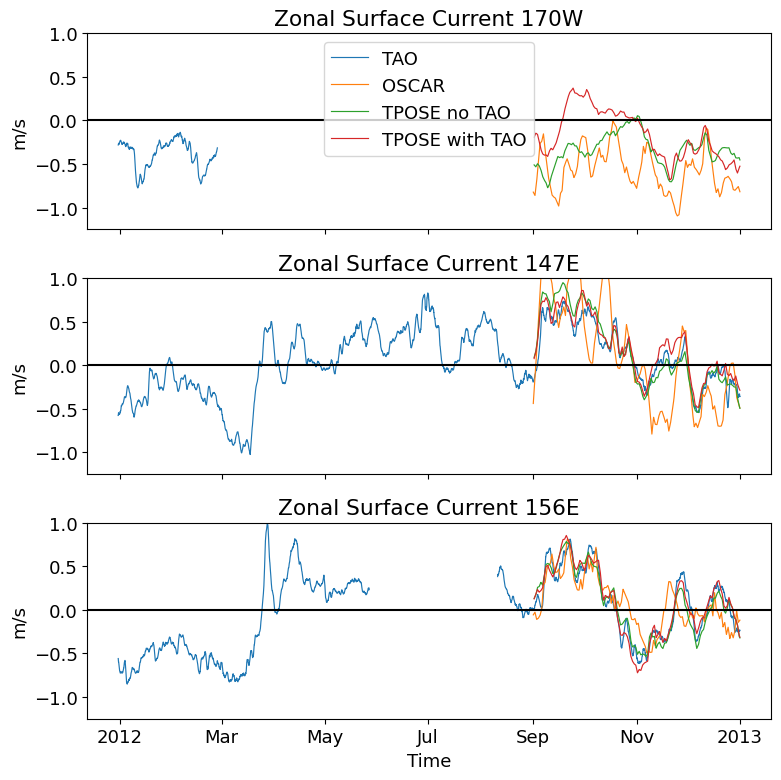

In [157]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,sharex=True)
tao_to_interp = cur_by_lon[-170.0].prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.u.interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))
tpose_notao_compare = tpose_noTAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))
tpose_tao_compare = tpose_TAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))

cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[0],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[0],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[0],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[0],x='time',lw=0.85,label='TPOSE with TAO')
ax[0].legend()
ax[0].set_xlabel('')
ax[0].set_ylabel('m/s')
ax[0].set_title('Zonal Surface Current 170W')

tao_to_interp = cur_by_lon[147.0].prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.u.interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))
tpose_notao_compare = tpose_noTAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))
tpose_tao_compare = tpose_TAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))

cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[1],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[1],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[1],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[1],x='time',lw=0.85,label='TPOSE with TAO')
# ax[1].legend()
ax[1].set_xlabel('')
ax[1].set_ylabel('m/s')
ax[1].set_title('Zonal Surface Current 147E')

tao_to_interp = cur_by_lon[156.0].prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.u.interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))
tpose_notao_compare = tpose_noTAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))
tpose_tao_compare = tpose_TAO_U.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))

cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_U.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[2],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[2],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[2],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[2],x='time',lw=0.85,label='TPOSE with TAO')
# ax[2].legend()
ax[2].set_xlabel('Time')
ax[2].set_ylabel('m/s')
ax[2].set_title('Zonal Surface Current 156E')

for ax in ax.flatten():
    ax.axhline(0,color='k')
    ax.set_ylim(-1.25,1.0)
plt.tight_layout()
fig.savefig(foldername + 'tpose_TAO_oscar_zonal_timseries_2012.png',dpi=300)

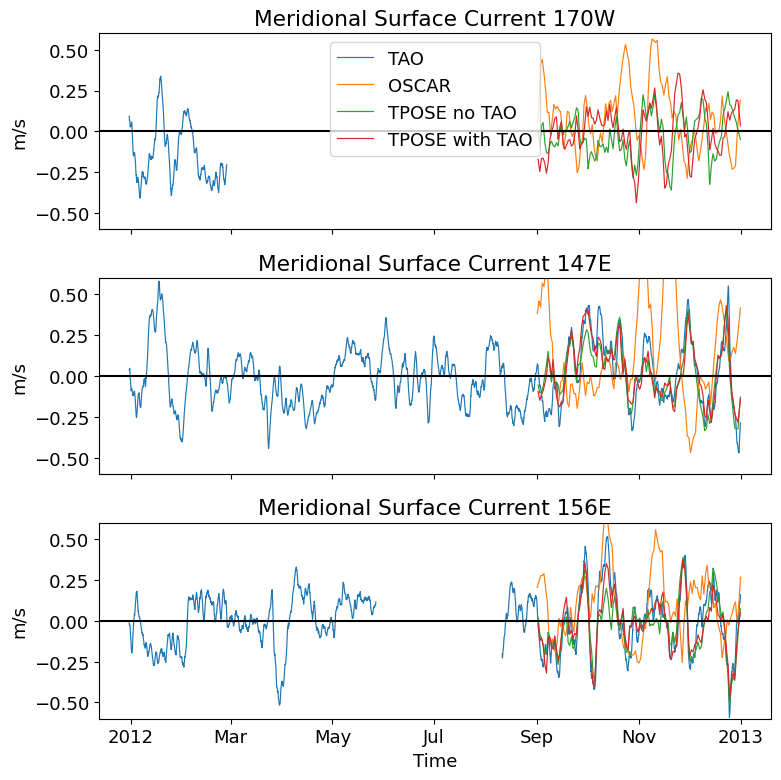

In [158]:
fig, ax = plt.subplots(figsize=(8,8),nrows=3,sharex=True)
tao_to_interp = cur_by_lon[-170.0].prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.v.interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))
tpose_notao_compare = tpose_noTAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))
tpose_tao_compare = tpose_TAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[-170.0].prof_lat,XC=(cur_by_lon[-170.0].prof_lon+360))

cur_by_lon[-170.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[0],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[0],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[0],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[0],x='time',lw=0.85,label='TPOSE with TAO')
ax[0].legend()
ax[0].set_xlabel('')
ax[0].set_ylabel('m/s')
ax[0].set_title('Meridional Surface Current 170W')

tao_to_interp = cur_by_lon[147.0].prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.v.interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))
tpose_notao_compare = tpose_noTAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))
tpose_tao_compare = tpose_TAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[147.0].prof_lat,XC=(cur_by_lon[147.0].prof_lon))

cur_by_lon[147.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[1],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[1],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[1],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[1],x='time',lw=0.85,label='TPOSE with TAO')
# ax[1].legend()
ax[1].set_xlabel('')
ax[1].set_ylabel('m/s')
ax[1].set_title('Meridional Surface Current 147E')

tao_to_interp = cur_by_lon[156.0].prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True)
oscar_tao_compare = ds_OSCAR.v.interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))
tpose_notao_compare = tpose_noTAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))
tpose_tao_compare = tpose_TAO_V.isel(Z=0).interp(time=tao_to_interp.time,YC=cur_by_lon[156.0].prof_lat,XC=(cur_by_lon[156.0].prof_lon))

cur_by_lon[156.0].sortby('time').isel(iDEPTH=0).prof_V.rolling(iPROF=24,center=True,min_periods=10).mean(skipna=True).plot(ax=ax[2],x='time',lw=0.85,label='TAO')
oscar_tao_compare.plot(ax=ax[2],x='time',lw=0.85,label='OSCAR')
tpose_notao_compare.plot(ax=ax[2],x='time',lw=0.85,label='TPOSE no TAO')
tpose_tao_compare.plot(ax=ax[2],x='time',lw=0.85,label='TPOSE with TAO')
# ax[2].legend()
ax[2].set_xlabel('Time')
ax[2].set_ylabel('m/s')
ax[2].set_title('Meridional Surface Current 156E')

for ax in ax.flatten():
    ax.axhline(0,color='k')
    ax.set_ylim(-0.6,0.6)
plt.tight_layout()
fig.savefig(foldername + 'tpose_TAO_oscar_meridional_timseries_2012.png',dpi=300)

In [153]:
client.shutdown()
cluster.close()
client.close()